In [1]:
from functools import partial
import random, sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import copy
import json
from collections import OrderedDict
import os
import pandas as pd
import seaborn as sns
import matplotlib as mpl
#sys.path.append("/users/romartinez/romartinez/repos/SRRM4_MapSy_2024")
import auxfuncs_fitting
sysfunc=auxfuncs_fitting.psi_linear_system_noalpha_lessparsv2
mpl.rcParams["pdf.fonttype"]=42
def rel_error(model,data):
    n=len(model)
    return np.sum(np.abs(model-data)/data)/n

In [3]:
outfolder_="2025_02_SRRM4fits/fitsmse_median_increasinginput_lessparsv2_range6"
dataf="subsetdata_median.json"
with open(os.path.join(outfolder_,dataf)) as f:
    d = json.load(f)

allgroups_subset=[]
centraldata_subset=[]
allindividual_subset=[]
for k,v in d.items():
    #if True:
    if not "U1cons_a" in k:
        allgroups_subset.append(k)
        if "endo" in k:
            v=list(np.asarray(v)[[0,1,2,4]])
        centraldata_subset.append(v)
        df=pd.read_csv(os.path.join("individual_subset_data","%s.csv"%k))
        if "Unnamed: 0" in df.columns:
            df=df.drop(columns=["Unnamed: 0"])
        df = df.apply(pd.to_numeric)
        allindividual_subset.append(df)
print(allgroups_subset)

['WTendo-LS', 'WTendo-HS', 'WTminigene-LS', 'WTminigene-HS', 'U1cons_b-LS', 'U1cons_b-HS', 'BP_stg1-LS', 'BP_stg1-HS', 'BP_weak3-LS', 'BP_weak3-HS']


In [4]:
all_fitness=[]
all_conditions=["c2", "c4"]
all_bestpars=[]
all_parsetnames=[]
all_pars_per_group=[]
for condition in all_conditions:
    outfolder=os.path.join(outfolder_,"out_%s"%condition)
    allfitness=[]
    allpars=[]
    for i in range(1,501):
        file=os.path.join(outfolder,"ubsetdata_media_out_%d.txt"%i)
        with open(file) as f:
            d=json.load(f)
            fitness=d["fitness"]
            pars=list(map(float,d["pars"]))
            allfitness.append(fitness)
            allpars.append(pars)
    bestidx=np.argmin(allfitness)
    bestpars=list(map(float,allpars[bestidx]))
    bestfiness=allfitness[bestidx]
    all_fitness.append(allfitness)
    all_bestpars.append(bestpars)
    all_parsetnames.append(d["parsetnames"])
    all_pars_per_group.append(d["pars_per_group"])


In [5]:
sns.set(style="ticks", context="talk", font_scale=0.75, font="Arial")

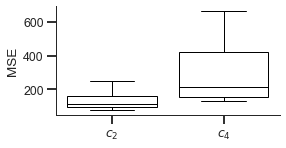

In [7]:
conditions=[]
for c in all_conditions:
    conditions.extend([c]*500)
#print(conditions)

subdf_data=pd.DataFrame({"error":[ x
    for xs in all_fitness
    for x in xs], "condition":conditions})
subdf_data["dataset"]="data"
fig,ax=plt.subplots(1,1,figsize=(4,2.))
sns.boxplot(x="condition",y="error",data=subdf_data,linecolor="black",color="white",showfliers=False)
ax.set_xticks(range(2))
ax.set_xticklabels([r"$c_2$", r"$c_4$"])
#ax.text(0.5,-170,"model II")
#ax.text(3.5,-170,"model I")
ax.set_ylabel("MSE")
ax.set_xlabel("")
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_linewidth(1)
ax.spines[['right', 'top']].set_visible(False)
#plt.savefig("./panels/errors_modelI_modelII.pdf",bbox_inches="tight",dpi=500, transparent=True)

In [8]:
#now merge all model I and all model II
subdf_data_merged=subdf_data.copy()
subdf_data_merged["model"]=""
subdf_data_merged.loc[subdf_data_merged["condition"].isin(["c1","c2","c1c2"]),"model"]="model II"
subdf_data_merged.loc[subdf_data_merged["condition"].isin(["c3_","c4","c3_c4"]),"model"]="model I"


In [9]:
subdf_data_merged

,error,condition,dataset,model
0,135.755287,c2,data,model II
1,98.088457,c2,data,model II
2,92.023148,c2,data,model II
3,101.685724,c2,data,model II
4,188.927126,c2,data,model II
...,...,...,...,...
995,276.209273,c4,data,model I
996,142.460180,c4,data,model I
997,143.671958,c4,data,model I
998,618.215316,c4,data,model I


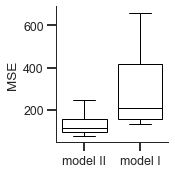

In [12]:
fig,ax=plt.subplots(1,1,figsize=(2,2.5))
sns.boxplot(x="model",y="error",data=subdf_data_merged,color="white",linecolor="black",showfliers=False)
ax.set_xlabel("")
ax.set_ylabel("MSE")
ax.spines[["top","right"]].set_visible(False)
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_linewidth(1)
plt.savefig("./panels/reduced_errors_modelI_modelII_main.pdf",bbox_inches="tight",dpi=500, transparent=True)

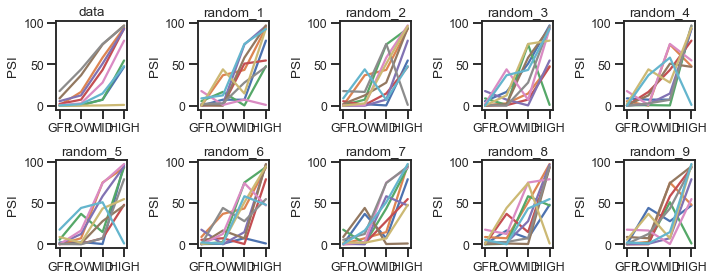

In [15]:
fig,axes=plt.subplots(2,5,figsize=(10,4))
for i in range(10):
    ax=axes[i//5][i%5]
    if i==0:
        datar=centraldata_subset
        ax.set_title("data")
    else:
        datar=np.loadtxt("./2025_02_SRRM4fits/mediandata_permut_%d.txt"%(i-1))
        ax.set_title("random_%d"%i)
    for k in range(len(datar)):
        ax.plot(range(4),datar[k])
        ax.set_xticks(range(4))
        ax.set_xticklabels(["GFP","LOW","MID","HIGH"])
        ax.set_ylabel("PSI")
        
plt.tight_layout()
plt.show()

{}
{}
{}
{}
{}
{}
{}
{}
{}


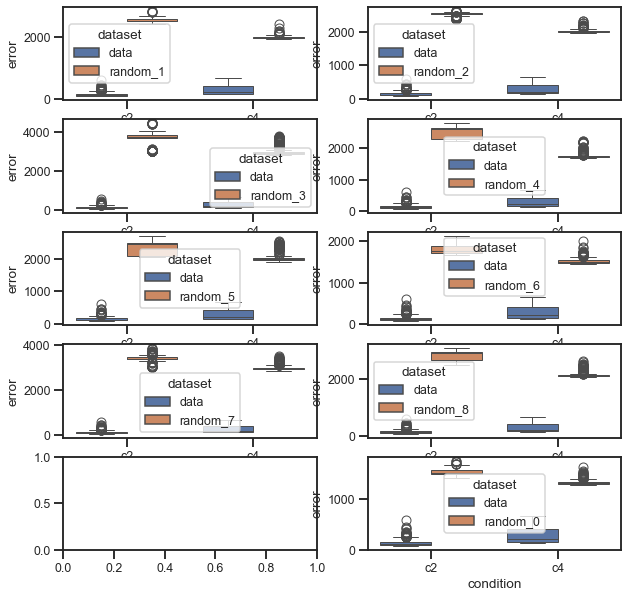

In [17]:
allsubdf_random=[]
fig,axes=plt.subplots(5,2,figsize=(10,10))
for random in range(9):
    ax=axes[(random-1)//2][(random-1)%2]
    rsubdf={}
    print(rsubdf)
    for c in all_conditions:
        allfitness=[]
        for i in range(1,501):
            file=f"./2025_02_SRRM4fits/fitsrandompermut_lessparsv2_range8/out_{c}/mediandata_permut_{random}_out_{i}.txt"
            if os.path.isfile(file):
                with open(file) as f:
                    d=json.load(f)
                fitness=d["fitness"]
                allfitness.append(fitness)
        rsubdf[c]=allfitness
        bestidx=np.argmin(allfitness)
        bestfitness=allfitness[bestidx]
        #print(bestfitness)
    subdf2=pd.DataFrame(rsubdf)
    subdf2=pd.melt(subdf2)
    subdf2.columns=["condition","error"]
    subdf2["dataset"]="random_%d"%random
    allsubdf=pd.concat([subdf_data,subdf2])
    sns.boxplot(x="condition",y="error",data=allsubdf,hue="dataset",ax=ax)
    allsubdf_random.append(subdf2)

In [18]:
allsubdf_random=pd.concat(allsubdf_random)

In [19]:
#merge all random 
#
allsubdf_random.loc[allsubdf_random["condition"].isin(["c1","c2","c1c2"]),"model"]="model II"
allsubdf_random.loc[allsubdf_random["condition"].isin(["c3_","c4","c3_c4"]),"model"]="model I"


In [20]:
allsubdf_random.head()

,condition,error,dataset,model
0,c2,1523.701980,random_0,model II
1,c2,1515.083769,random_0,model II
2,c2,1517.378079,random_0,model II
3,c2,1507.212480,random_0,model II
4,c2,1633.265238,random_0,model II


In [21]:
subdf_data_merged.head()

,error,condition,dataset,model
0,135.755287,c2,data,model II
1,98.088457,c2,data,model II
2,92.023148,c2,data,model II
3,101.685724,c2,data,model II
4,188.927126,c2,data,model II


In [22]:
data_and_random=pd.concat([allsubdf_random,subdf_data_merged])
data_and_random.loc[data_and_random["dataset"].str.startswith("random"),"dataset"]="random"

In [23]:
combined_dataset=pd.DataFrame()
combined_dataset

""


In [24]:
sns.set(style="ticks", context="talk", font_scale=0.55, font="Arial")

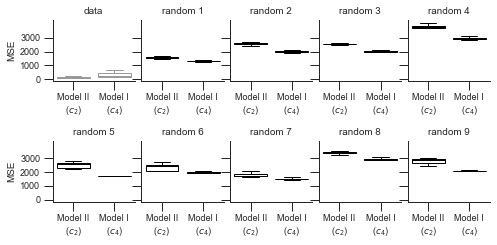

In [38]:
fig, axes = plt.subplots(2, 5, figsize=(7, 3.5),sharey=True)  # 2 rows, 5 columns
axes = axes.flatten()  # Flatten to easily iterate

# Create boxplots for each "random_i" group
ax=axes[0]
sns.boxplot(x="condition", y="error", data=subdf_data, ax=ax,color="white",showfliers=False)
ax.set_title("data")
ax.set_xlabel("")
for i in range(9):
    
    subset = allsubdf_random[allsubdf_random["dataset"]=="random_%d"%(i)]  
    sns.boxplot(x="condition", y="error", data=subset, ax=axes[i+1],color="white",linecolor="black",showfliers=False)
    axes[i+1].set_title(f"random_{i+1}")  # Set title
    axes[i+1].set_xlabel("")  # Hide x-label
    axes[i+1].set_ylabel("error")  # Label for y-axis
    #axes[i].set_ylim(0,8500)

for ax in axes:
    ax.set_xticks(range(2))
    ax.set_xticklabels(["Model II\n"+r"($c_2$)", "Model I\n"+r"($c_4$)"])
    ax.set_yticks([0,1000,2000,3000])
    ax.spines[['right', 'top']].set_visible(False)
    ax.spines['left'].set_linewidth(1)
    ax.spines['bottom'].set_linewidth(1)
    ax.xaxis.set_tick_params(width=1)
    ax.yaxis.set_tick_params(width=1)
ax=axes[0]
ax.set_ylabel("MSE")
ax=axes[5]
ax.set_ylabel("MSE")
for i,ax in enumerate(axes[1:]):
    ax.set_title("random %d"%(i+1))
#plt.tight_layout()  # Adjust spacing
#plt.show()
    


plt.tight_layout(w_pad=-0.25)  # Adjust spacing
plt.savefig("./panels/reduced_errors_data_random.pdf",bbox_inches="tight",dpi=500, transparent=True)
plt.savefig("./panels/reduced_errors_data_random.svg",bbox_inches="tight")
plt.show()


In [27]:
all_conditions

['c2', 'c4']

LOW 10.32537581924918
HIGH 449.9392679716821
c2:WTendo-LS 37983.63517318548
c2:WTendo-HS 549.755338728305
c2:WTminigene-LS 28537.583088400497
c2:WTminigene-HS 2101.130358174844
c2:U1cons_b-LS 1029.8678126626844
c2:U1cons_b-HS 47.51488195750786
c2:BP_stg1-LS 7179.343605882227
c2:BP_stg1-HS 1e-06
c2:BP_weak3-LS 1000000.0
c2:BP_weak3-HS 33636.32223165459
c4 116.63118607963425
c7 1390.9876993454131
ke 3.077893645398949
kis 97.81542673987092


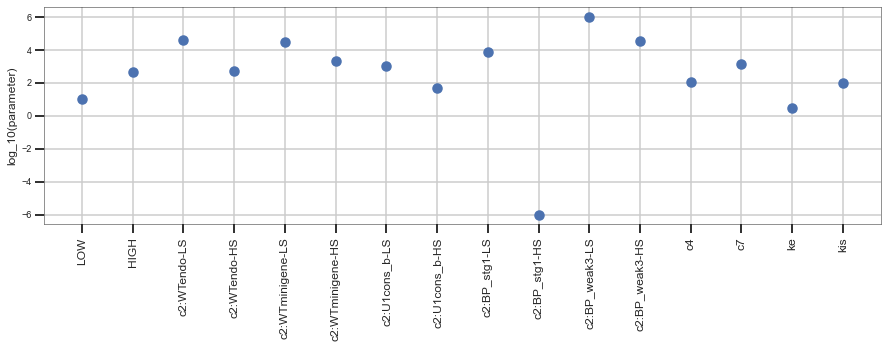

WTendo-LS model-data: [(0.08337416895988982, 0.0), (0.9752863337252703, 0.93), (8.038294942663684, 7.37), (46.79337875747571, 46.99)]
WTendo-LS error: 0.12357003686842084 without mean: 0.9935766878731388
WTendo-HS model-data: [(4.650081505485811, 0.47), (15.242686768093003, 16.67), (57.167442955098366, 58.14), (94.26761249089236, 94.25)]
WTendo-HS error: 5.114120464976138 without mean: 6.597564273186805
WTminigene-LS model-data: [(0.1108426806842917, 0.1775), (1.2695421075865292, 0.6525), (10.23456273191307, 7.175), (53.57552822482499, 54.707499999999996)]
WTminigene-LS error: 2.756867092764349 without mean: 4.875233933990311
WTminigene-HS model-data: [(1.4220483721302877, 2.1550000000000002), (8.596690533358341, 7.285), (44.1505306186635, 43.2875), (90.2738491949977, 93.32249999999999)]
WTminigene-HS error: 3.0742109309226513 without mean: 5.956323584893851
U1cons_b-LS model-data: [(2.7313163729519268, 5.449999999999999), (11.907564422808681, 12.485), (51.84273109055483, 50.865), (92.

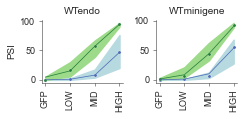

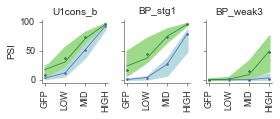

LOW 7.342908012238768
HIGH 117.62139242474883
c2 1000000.0
c4:WTendo-LS 3381.7247359084513
c4:WTendo-HS 94.21563738042931
c4:WTminigene-LS 2478.619094646129
c4:WTminigene-HS 212.39060845432394
c4:U1cons_b-LS 143.65220738288957
c4:U1cons_b-HS 10.179521462406287
c4:BP_stg1-LS 554.1350334645147
c4:BP_stg1-HS 1e-06
c4:BP_weak3-LS 1000000.0
c4:BP_weak3-HS 3055.5238135360123
c7 1034.6209483295634
ke 1.4706576409591277
kis 38193.42612898651


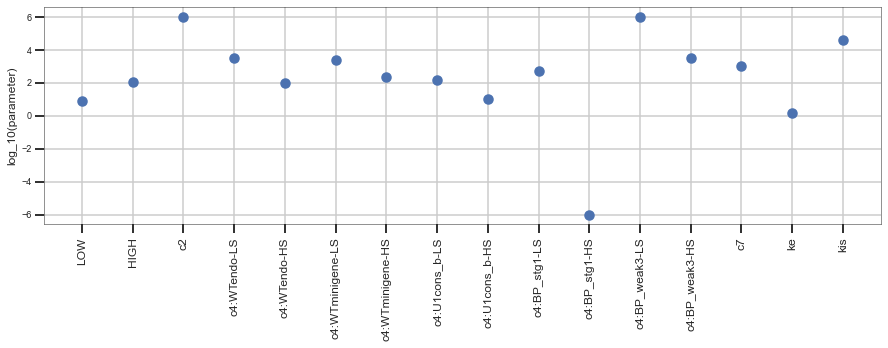

WTendo-LS model-data: [(2.4404368468007775, 0.0), (3.153600099602257, 0.93), (7.436294647149777, 7.37), (46.90932920979133, 46.99)]
WTendo-LS error: 2.7277580407019233 without mean: 4.811002383761482
WTendo-HS model-data: [(2.4404368468007775, 0.47), (17.814887983027553, 16.67), (57.80064492910903, 58.14), (92.3742631314187, 94.25)]
WTendo-HS error: 2.206735131301419 without mean: 5.330416769300595
WTminigene-LS model-data: [(2.4404368468007775, 0.1775), (3.4067367890524234, 0.6525), (9.100845358148563, 7.175), (54.08089949940556, 54.707499999999996)]
WTminigene-LS error: 4.202052998406503 without mean: 7.569619494596199
WTminigene-HS model-data: [(2.4404368468007775, 2.1550000000000002), (11.281422015708058, 7.285), (43.075143226683394, 43.2875), (89.18618996029197, 93.32249999999999)]
WTminigene-HS error: 8.30175481622761 without mean: 8.630525675533464
U1cons_b-LS model-data: [(2.4404368468007775, 5.449999999999999), (14.184301014378219, 12.485), (50.512913996605256, 50.865), (91.01

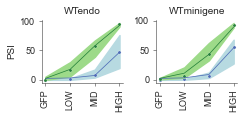

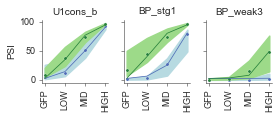

In [33]:
minv=-6
maxv=6
ratenames="c2,c4,c7,ke,kis".split(",") #parameters of the function to calculate psi
inputnames_mini="GFP,CTR,LOW,HIGH".split(",") #minigene
inputnames_endo="GFP,CTR,LOW,HIGH".split(",") #endogenous
fixedpars=OrderedDict({"GFP":0,"CTR":1})  #natural scale. 
parranges={'c7':[0,maxv],'c8':[minv,0],"LOW":[0,3],"HIGH":[0,3]}
additional_data=[x.values[~np.all(np.isnan(x.values),axis=1)] for x in allindividual_subset]
data=centraldata_subset
groups=allgroups_subset
titles=groups

for c_,condition in enumerate(all_conditions):
    parsetnames=all_parsetnames[c_]
    pars=all_bestpars[c_]
    pars_per_group=all_pars_per_group[c_]
    npars=len(parsetnames)
    
    for i in range(len(parsetnames)):
        print(parsetnames[i],10**float(pars[i]))
    
    pars_per_group_refine=pars_per_group
    
    getparskwargs=auxfuncs_fitting.return_parsdict(groups,inputnames=inputnames_endo,pars_per_group=pars_per_group, pars_per_group_refine=pars_per_group_refine,ratenames=ratenames, minv=minv, maxv=maxv, parranges=parranges,fixedpars=fixedpars)
    
    npars=len(getparskwargs["inputnames"])+len(getparskwargs["ratenames"])
    idxsdictname="idxsdict_refine" #these come from refined parameter sets, so c2 and kis change
    
    allparsets=auxfuncs_fitting.get_parameters_per_group(pars,npars=npars,**getparskwargs, **getparskwargs[idxsdictname])
    ninput=4
    mask_input=getparskwargs["mask_input"]
    
    c=-1
   
    #titles
    
    #plot parameter values
    fig1,ax=plt.subplots(1,1,figsize=(15,4),sharex=True)
    #ax=sns.scatterplot(x=range(len(pars)),y=pars)
    ax.scatter(range(len(pars)),pars)
    ax.set_xticks(range(len(pars)))
    ax.set_xticklabels(parsetnames,rotation=90,fontsize=12)
    ax.spines[['left', 'bottom','right','top']].set_linewidth(.5)
    ax.grid("on")
    ax.set_ylabel("log_10(parameter)",fontsize=12)
    plt.show()
    mask_input_endo=[True,True,True,False,True]
    for j in range(1):
        figWT,axesWT=plt.subplots(1,2,figsize=(3.5,1.75))
        figmut,axesmut=plt.subplots(1,3,figsize=(4,1.75),sharex=True, sharey=True)
        #figrest,axesrest=plt.subplots(1,5, figsize=(12,4),sharex=True,sharey=True)
        #axesrest=axesrest.flatten()
        i=0
        i_=0
        for g in range(len(allparsets)):
            label=titles[g]
            xvec_psi=allparsets[g,0:ninput][mask_input[g]]
            #print(xvec_psi)
            #range_n=np.where(mask_input[g])[0]
            #range_n=np.arange(4)
    
            rates=allparsets[g,ninput:]
            model_g=auxfuncs_fitting.out_event(rates,xvec_psi,solve_linear_system=sysfunc)
            data_g=np.asarray(data[g]) #trend (median)
            error=auxfuncs_fitting.mserror(model_g,data_g)
            print(label, "model-data:", list(zip(model_g, data_g)))
            print(label, "error:", error, "without mean:", np.sum(np.abs(model_g-data_g)))
            data_g_a=additional_data[g]
            if "endo" in label:
                #remove 4th point, which is not present in the rest
                model_g=model_g
                data_g=data_g
                data_g_a=data_g_a[:None,mask_input_endo]
            #print(model_i)
            if g<2:
                ax=axesWT[0]
            elif g<4:
                ax=axesWT[1]
            elif label.strip("-LS").strip("-HS") in ["U1cons_b","BP_stg1","BP_weak3"]:
                ax=axesmut[i_]
                if "HS" in label:
                    i_+=1
            else:
                print("wrong category")
                #ax=axesrest[i]
                #if "HS" in label or "CS" in label:
                #    i+=1
    
            
            q25=np.quantile(data_g_a,0.25,axis=0)
            q75=np.quantile(data_g_a,0.75,axis=0)
            range_n=np.arange(len(model_g))
            if "LS" in label:
                color="#4e6cb7ff"
                fillcolor="#b7dae1ff"
            else:
                color="#26813aff"
                fillcolor="#9dda89ff"
            if j==0: 
                ax.fill_between(range_n,q25,q75,color=fillcolor)
                ax = sns.scatterplot(x=range_n,y=data_g,color=color,marker="o",s=10,ax=ax)
                ax = sns.lineplot(x=range_n, y=model_g, linewidth = .75,color=color,ax=ax)
                
            else:
                #for l in range(len(data_g_a)):
                #    data_l=data_g_a[l]
                #    if np.all(~np.isnan(data_l)):
                #        ax = sns.lineplot(x=range_n,y=data_l,color=fillcolor,ax=ax,linewidth=0.5)
                ax=sns.scatterplot(x=range_n,y=data_g,color=color,marker="o",s=10,ax=ax)
                ax=sns.lineplot(x=range_n,y=model_g,color=color,ax=ax,linewidth = .75)
                #ax.scatter(range_n,data_g,color=color,marker="o",s=10)
                #ax.plot(range_n, model_g, linewidth = .75,color=color)
            ax.spines[['left', 'bottom']].set_linewidth(.5)
            ax.spines[['right', 'top']].set_linewidth(0)
            ax.xaxis.set_tick_params(width=0.5, length=3)
            ax.yaxis.set_tick_params(width=0.5, length=3)
    
            #ax.legend()
            #ax.set_xticks()
            ax.set_title(titles[g].strip("-HS").strip("-LS").replace(";","\n"),fontsize=10)
            ax.set_xticks(range(4))
            ax.set_xticklabels(["GFP","LOW","MID","HIGH"],rotation=90)
        axesWT[0].set_ylabel("PSI")
        axesmut[0].set_ylabel("PSI")
        #axesrest[0].set_ylabel("PSI")
        #axesrest[7].set_ylabel("PSI")
        figWT.tight_layout()
        figWT.savefig("./panels/reduced_WT_%s.pdf"%condition)
        figWT.savefig("./panels/reduced_WT_%s.svg"%condition)
        figmut.tight_layout()
        figmut.savefig("./panels/reduced_figmut_%s.pdf"%condition)
        figmut.savefig("./panels/reduced_figmut_%s.svg"%condition)
        #figrest.tight_layout()
        #figmut.savefig("./panels/figrest_%d.pdf"%j)
        plt.show()
                  